# Dubins Car Challenge
DD2410 — Planning Assignment <br/>

# Description

In this assignment you're tasked to implement a robotic planning method to drive a Dubins car with the dynamics
$$
\left[
\begin{matrix}
\frac{dx}{dt} \\
\frac{dy}{dt} \\
\frac{d\theta}{dt} \\
\end{matrix}\right]
=
\left[
\begin{matrix}
\cos \theta \\
\sin \theta \\
\tan \phi(t)
\end{matrix}
\right]
$$
from an initial position $(x_0, y_0)$ to a target position $(x_f, y_f)$, while avoiding collisions with obstacles and going out of bounds.

## Variables
The state variables are
\begin{matrix}
x & = & \text{horizontal position} \\
y & = & \text{vertical position} \\
\theta & = & \text{heading position}
\end{matrix}
and the control is
$$
\phi(t) = [-\pi/4, \pi/4] = \text{steering angle}.
$$

# Tasks

We'll consider two graded tasks in order of difficulty:
 - **E** — reach the target with circular obstacles;
 - **C** — reach the target with line obstacles.
 
**Note**:
- the line obstacles are represented by a series of circular obstacles,
- the initial and target positions are randomised,
- and the obstacle in Kattis are different.

# Your solution file
Using the API (see `README.md`) and a robotic planning method, generate a sequence of steering angle commands `controls` and a sequence of times `times`, between which the commands are executed, that would yield a collision-free and task-fulfilling trajectory.

Do this by editing the function `solution(car)` contained in the file `solution.py`. If needed, supporting code can be added outside the `solution(car)` function.

The template solution looks like this:

```python
def solution(car):

    ''' <<< write your code below >>> '''
    controls=[0]
    times=[0,1]

    ''' <<< write your code above >>> '''

    return controls, times
```

## The solution function
The solution function `solution(car)` recieves a `Car` instance `car` and returns a tuple containing
 - `controls : list`: sequence of steering angles `controls[i] : float`
 - `times : list`: sequence of times at which the controls are executed `times[i] : float`

**Note**: `controls[i]` is considered to be constant between `times[i]` and `times[i+1]`, hence `len(controls) == len(times) - 1`.

## The `Car` object
The `Car` object has several attributes which you may find useful, namely:
 - `x0 : float`: initial x-position
 - `y0 : float`: initial y-position
 - `xt : float`: target x-position
 - `yt : float`: target y-position
 - `xlb : float`: minimum x-position
 - `xub : float`: maximum x-position
 - `ylb : float`: minimum y-position
 - `yub : float`: maximum y-position
 - `obs : list`: list of tuples for each obstacle `obs[i]`, where:
   - `obs[i][0] : float`: x-position
   - `obs[i][1] : float`: y-position
   - `obs[i][2] : float`: radius

**Note**: these attributes should not be edited.

In [1]:
from dubins import Car
car = Car()
print(car.__dict__)

{'_environment': <dubins.Environment object at 0x10f288f50>, 'x0': 0.0, 'y0': 1.5224155884246118, 'xt': 20.0, 'yt': 6.599318812193834, 'obs': [(4.807665352269916, 5.387586250548669, 0.6445730572102437), (5.431469755845734, 8.399536555884877, 0.5263129257342585), (12.229620807293795, 1.3986867325622387, 0.7185054458903236), (12.86863485622466, 8.661533942816222, 0.5855033406619923), (9.26429532282706, 1.667105804531921, 0.6087382626681964), (9.125090640076124, 7.811157812965665, 0.6558251639376492), (5.0122529486921135, 2.802233466244287, 0.6419490378816104), (8.665027928318064, 4.740289316680101, 0.7461944795712515), (12.132943116492603, 5.4187643884919545, 0.5523784303624646), (15.342321983555461, 3.9016112461034744, 0.6267585555992181), (6.217028139816559, 0.8762432592599745, 0.5297904121007294), (14.469783255354564, 6.682344950848789, 0.6002704645468915), (14.881801362666174, 0.8138687253006672, 0.7933163717756178), (10.69567003746207, 3.333857737015282, 0.5714294710968567), (7.4129

## The `step` function
The method that you'll need to utilise in your implementation of robotic planning methods is `step(car, x, y, theta, phi)` (imported from `dubins`), which takes as its arguments:
 - `car : Car`: instance of `Car`
 - `x : float`: x-position
 - `y : float`: y-position
 - `theta : float`: heading angle
 - `phi : float`: steering angle
 - `dt=0.01: float`: time-step size

and returns a tuple of the form `(xn, yn, thetan)` after `dt` seconds, containing:
 - `xn : float`: new x-position
 - `yn : float`: new y-position
 - `thetan : float`: new heading angle

**Note**: `dt` should not be below 0.01s.

After computing the new state `xn, yn, thetan = step(car, x, y, theta, phi)`, check `car.obs` to see if the new state is within any obstacles, `(car.xlb, car.xub, car.ylb, car.yub)` to see if it is out of bounds, and `(car.xt, car.yt)` to see if it is close the the target state.

## Taking a single step

In [7]:
from dubins import step

# arbitrary heading and steering angle
theta, phi = 0.0, 0.1

# take a step
step(car, car.x0, car.y0, theta, phi, dt=0.1)

(0.1, 8.78604010126979, 0.010033467208545055)

## Recording multiple steps

In [8]:
# trajectory: x, y, theta, phi, time
xl, yl, thetal, phil, tl = [car.x0], [car.y0], [0.0], [], [0.0]

# simulate for 1 seconds (10 * 0.1s = 1s) with constant steering angle phi = 0.1
phi = 0.1
for _ in range(10):
    xn, yn, thetan = step(car, xl[-1], yl[-1], thetal[-1], phi, dt=0.1)
    xl.append(xn)
    yl.append(yn)
    thetal.append(thetan)
    phil.append(phi)
    tl.append(tl[-1] + 0.1)

print('The state after 10s is (x={:.3f}, y={:.3f}, theta={:.3f})'.format(
    xl[-1], yl[-1], thetal[-1]
))
print('The controls and times were:\n phi={} \n t={}'.format(phil, tl))

The state after 10s is (x=0.999, y=8.831, theta=0.100)
The controls and times were:
 phi=[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] 
 t=[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999]


# Creating a solution

In [ ]:
def solution(car):

    # trajectory: x, y, theta, phi, time
    x, y = car.x0, car.y0
    xl, yl, thetal, phil, tl = [x], [y], [0.0], [], [0.0]

    # simulate for 10 seconds with constant steering angle
    phi = -0.2
    for _ in range(2000):
        xn, yn, thetan = step(car, xl[-1], yl[-1], thetal[-1], phi, dt=0.1)
        xl.append(xn)
        yl.append(yn)
        thetal.append(thetan)
        phil.append(phi)
        tl.append(tl[-1] + 0.1)

    # return controls and times
    return phil, tl

In [9]:
# Utils:
from math import atan2, atan, sin, pi

def wrap_to_pi(a):
    while a <= -pi:
        a += 2*pi
    while a > pi:
        a -= 2*pi
    return a

def clamp(v, lo, hi):
    return lo if v < lo else hi if v > hi else v

def euclidean_norm(dx, dy): # magnitude of vector (dx, dy) 
    return (dx**2 + dy**2)**0.5

def euclidean_distance_between_points(x1, y1, x2, y2):
    return ((x2 - x1)**2 + (y2 - y1)**2)**0.5

In [ ]:
# pseudocode for Theta*: https://en.wikipedia.org/wiki/Theta*

import heapq

def line_of_sight(a, b, occ, nx, ny):
    """
    Bresenham-style line-of-sight check on a grid.

    a, b: (ix, iy) integer grid cells
    occ: 2D bool grid where occ[ix][iy] == True means occupied
    nx, ny: grid size

    Returns True if every traversed cell on the line is inside bounds and free.
    """
    x0, y0 = a
    x1, y1 = b

    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)

    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1

    err = dx + dy  # dy is negative

    while True:
        # bounds + occupancy check
        if not (0 <= x0 < nx and 0 <= y0 < ny):
            return False
        if occ[x0][y0]: # if cell is occupied, no line of sight
            return False

        if x0 == x1 and y0 == y1:
            return True

        e2 = 2 * err
        if e2 >= dy:
            if x0 == x1:
                return True
            err += dy
            x0 += sx
        if e2 <= dx:
            if y0 == y1:
                return True
            err += dx
            y0 += sy


def theta_star_grid(start, goal, occ, nx, ny):
    """
    Theta* any-angle path planning on an 8-connected grid.

    start, goal: (ix, iy)
    occ: 2D bool grid where occ[ix][iy] == True means occupied
    nx, ny: grid size

    Returns: list of cells [(ix, iy), ...] or None if no path found.
    """
    # 8-connected neighbors
    nbrs = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

    def heuristic(c): # based on Euclidean distance in grid coordinates
        return euclidean_distance_between_points(goal[0], goal[1], c[0], c[1])
    
    def cost(a, b): 
        return euclidean_distance_between_points(b[0], b[1], a[0], a[1])

    # gScore + parent
    g = {start: 0.0}
    parent = {start: start}

    openh = [(heuristic(start), start)]  # (f, node)
    closed = set()

    while openh:
        _, s = heapq.heappop(openh)
        if s in closed:
            continue
        closed.add(s)

        if s == goal:
            # reconstruct path
            path = [s]
            while parent[path[-1]] != path[-1]:
                path.append(parent[path[-1]])
            path.reverse()
            return path

        sx, sy = s
        ps = parent[s]

        for dx, dy in nbrs:
            nb = (sx + dx, sy + dy)
            nx2, ny2 = nb

            if not (0 <= nx2 < nx and 0 <= ny2 < ny):
                continue
            if occ[nx2][ny2]: # if cell is occupied, no path through it
                continue
            if nb in closed:
                continue

            # Ensure neighbor has entries
            # Initialize values for neighbor if it is 
            # not already in the open list
            if nb not in g:
                g[nb] = float("inf")
                parent[nb] = None

            # This part of the algorithm is the main difference between A* and Theta*
            # --- update_vertex(s, nb) ---
            # If line-of-sight(parent(s), nb), try bypassing s
            if ps is not None and line_of_sight(ps, nb, occ, nx, ny):
                cand = g[ps] + cost(ps, nb)
                if cand < g[nb]:
                    g[nb] = cand
                    parent[nb] = ps
                    heapq.heappush(openh, (g[nb] + heuristic(nb), nb))
            else:
                cand = g[s] + cost(s, nb)
                if cand < g[nb]:
                    g[nb] = cand
                    parent[nb] = s
                    heapq.heappush(openh, (g[nb] + heuristic(nb), nb))

    return None

In [ ]:
import heapq
from dubins import *  # provides step()

# A* planner:
def astar_path_planner(start, goal, occ_grid, nx, ny):
    """
    A* on an 8-connected grid.

    start, goal: (ix, iy)
    occ: 2D boolean grid where occ[ix][iy] == True means occupied
    nx, ny: grid dimensions

    Returns: list of cells [(ix,iy), ...] or None
    """
    neighbours = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

    def heuristic(a, b): # based on Euclidean distance in grid coordinates
        return euclidean_distance_between_points(a[0], a[1], b[0], b[1])

    openh = [(heuristic(start, goal), 0.0, start)]  # (f, g, node) open heap
    came  = {start: None} # best known parent for each cell
    gbest = {start: 0.0} # best known g score for each cell
    visited  = set() # closed set (visited cells)

    while openh:
        _, g, cur = heapq.heappop(openh)
        if cur in visited:
            continue
        visited.add(cur) # mark current cell as visited

        if cur == goal: # reconstruct path
            path = []
            while cur is not None:
                path.append(cur)
                cur = came[cur] # move backwards through parents to reconstruct path
            return path[::-1] # reverse path to get from start to goal

        cx, cy = cur
        for dx, dy in neighbours:
            nx2, ny2 = cx + dx, cy + dy
            if not (0 <= nx2 < nx and 0 <= ny2 < ny): # if cell is out of bounds, skip
                continue
            if occ_grid[nx2][ny2]: # if cell is occupied, skip
                continue

            nxt = (nx2, ny2) # neighbour cell
            ng = g + euclidean_norm(dx, dy) # cost to move to neighbour (neighbour g score)

            if ng < gbest.get(nxt, 1e18):
                gbest[nxt] = ng
                came[nxt] = cur
                heapq.heappush(openh, (ng + heuristic(nxt, goal), ng, nxt)) # push neighbour to open heap with f = g + h

    return None

# Pure pursuit tracker/controller:
def pure_pursuit_controller(car, waypoints, dt=0.01, Ld=1.0, waypoint_tol=0.5, t_max=80.0):
    """
    Tracks waypoints using pure pursuit.

    Returns: (controls, times)
    """
    max_phi = pi / 4

    # Initial state
    x, y, theta = car.x0, car.y0, 0.0
    t = 0.0
    controls = []
    times = [0.0]
    wi = 0

    def done_xy(x, y): # when we're close enough to the goal, we can stop
        return euclidean_distance_between_points(x, y, car.xt, car.yt) < 1.5

    while t < t_max and not done_xy(x, y):
        # advance index if close (checkpoint completed --> go to next checkpoint). "Did I reach this waypoint?"
        while wi < len(waypoints) - 1 and euclidean_distance_between_points(waypoints[wi][0], waypoints[wi][1], x, y) < waypoint_tol: # if we're close to the current waypoint, advance to the next one
            wi += 1

        # Pure Pursuit lookahead target selection: choose a target at least Ld away (aim further ahead so steering is smoother). "Where should I aim right now?"
        tj = wi
        while tj < len(waypoints) - 1 and euclidean_distance_between_points(waypoints[tj][0], waypoints[tj][1], x, y) < Ld: # if the current target is too close, try pushing forward to find a further target
            tj += 1
        tx, ty = waypoints[tj]

        heading_to_target = atan2(ty - y, tx - x)
        heading_err = wrap_to_pi(heading_to_target - theta) # heading error to target position. theta is the current heading of the car, so this is how much we need to turn to face the target
        kappa = 2.0 * sin(heading_err) / max(Ld, 1e-6) # curvature to reach target (pure pursuit control law)
        phi = clamp(atan(kappa), -max_phi, max_phi) # steering angle command (clamped to max_phi)

        x, y, theta = step(car, x, y, theta, phi, dt=dt)

        controls.append(phi)
        t += dt
        times.append(t)

    return controls, times


def solution(car):
    env = car._environment # 20x10 environment described by a rectangle [(0,0),(20,0),(20,10),(0,10)], containing n circular obstacles of radius r, positioned randomly within

    # Create occupancy grid representation + obstacle inflation
    res = 0.25 # grid resolution (smaller = better but slower)
    margin = 0.55 # inflate obstacles margin
    inflated = [(ox, oy, r + margin) for (ox, oy, r) in car.obs]

    nx = int(env.lx / res) + 1 # number of grid cells in x direction
    ny = int(env.ly / res) + 1 # number of grid cells in y direction

    def safe_inflated(x, y): # returns true (safe) if (x, y) is in bounds and not in collision with any inflated obstacle
        if x < 0 or x > env.lx or y < 0 or y > env.ly:
            return False
        for (ox, oy, rr) in inflated:
            if euclidean_distance_between_points(x, y, ox, oy) <= rr:
                return False
        return True

    def to_cell_coordinates(x, y): # to grid coordinates (ix, iy)
        ix = int(round(x / res))
        iy = int(round(y / res))
        return max(0, min(nx - 1, ix)), max(0, min(ny - 1, iy))

    def to_world_coordinates(ix, iy): # to world coordinates (x, y) at cell center
        return ix * res, iy * res

    # Build occupancy grid
    occ_grid = [[False] * ny for _ in range(nx)]
    for ix in range(nx):
        x = ix * res
        for iy in range(ny):
            y = iy * res
            if not safe_inflated(x, y):
                occ_grid[ix][iy] = True # occupied cell
            else:
                occ_grid[ix][iy] = False # free cell

    start = to_cell_coordinates(car.x0, car.y0) # transform start position to grid coordinates 
    goal  = to_cell_coordinates(car.xt, car.yt) # transform goal position to grid coordinates

    # ____________________________________________________________________________________________________

    # Use A*:
    # cells = astar_path_planner(start, goal, occ_grid, nx, ny) # plan path in grid coordinates (list of cells) using A*
    # if cells is None:
    #     # fallback: no path found; return a minimal valid output
    #     return [0.0], [0.0, 0.01]
    # waypoints = [to_world_coordinates(ix, iy) for (ix, iy) in cells] # convert path from grid coordinates to world coordinates (list of waypoints)

    # ____________________________________________________________________________________________________

    # Use Theta*:
    cells = theta_star_grid(start, goal, occ_grid, nx, ny)
    if cells is None:
        # fallback: no path found; return a minimal valid output
        return [0.0], [0.0, 0.01]
    waypoints = [to_world_coordinates(ix, iy) for (ix, iy) in cells]  # then feed to pure pursuit

    # ____________________________________________________________________________________________________

    controls, times = pure_pursuit_controller(car, waypoints, dt=0.01, Ld=1.0, waypoint_tol=0.5, t_max=80.0) # track waypoints with pure pursuit controller to get controls and times

    return controls, times

## Evaluating your solution

Grade E: 6/6 cases passed.
Grade C: 6/6 cases passed.


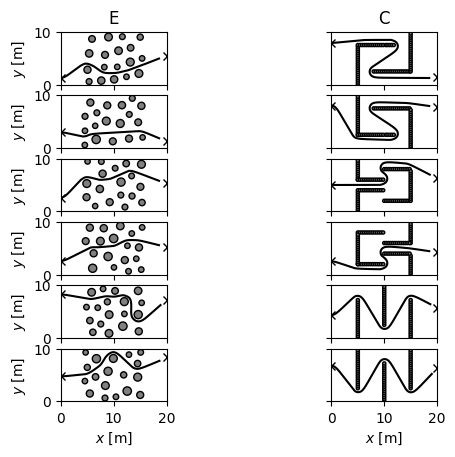

In [ ]:
%matplotlib inline
from main import main
# Using Theta* + pure pursuit tracking
main(solution, plot=True, verbose=False)

# Theta* gives a straighter, less zig-zag path than A* because it “skips corners” whenever there’s line-of-sight.

Grade E: 6/6 cases passed.
Grade C: 6/6 cases passed.


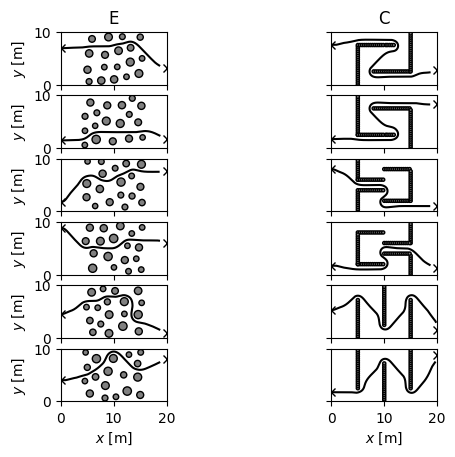

In [3]:
%matplotlib inline
from main import main
# Using A* + pure pursuit tracking
main(solution, plot=True, verbose=False)

Once you're done editing `solution.py`, you can also evaluate how well in the terminal by executing
- `python3 main.py`,
- `python3 main.py -p` for plotting,
- `python3 main.py -v` for step feedback,
- or `python3 main.py -p -v` for both.

**Note**: 
- you must install `matplotlib` for plotting to work,
- simulation is done at `dt=0.01` between `times[i]` and `times[i+1]`.

A succesful solution will generate something like this:
```bash
python3 main.py -p
```
```bash
Grade E: 6/6 cases passed.
Grade C: 6/6 cases passed.
```
![](plot.png)

# Useful resources
- [PythonRobotics](https://github.com/AtsushiSakai/PythonRobotics#path-planning) for planning algorithms,
- [demo.ipynb](demo.ipynb) for this assignment's introduction.